(60000, 28, 28) (10000, 28, 28)
(60000, 784) (10000, 784)


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,182,874 (4.51 MB)

 Trainable params: 1,182,874 (4.51 MB)

 Non-trainable params: 0 (0.00 B)

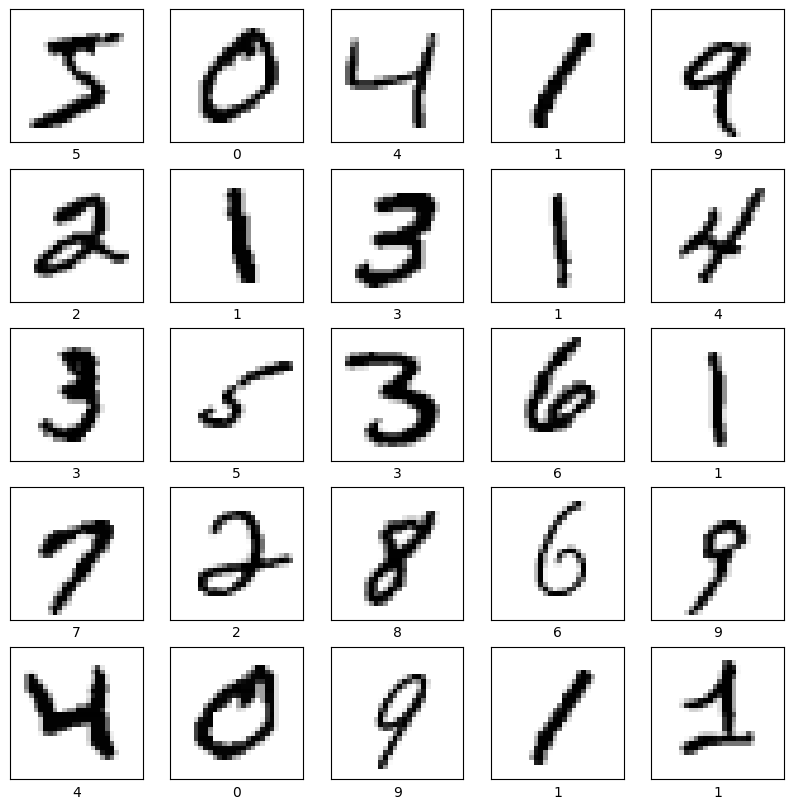

In [2]:
# 1. Deep MLP on the MNIST dataset. try to get over 98% test accuracy

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


np.random.seed(42)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
    

x_train = x_train.astype("float32") / 255.0 # normalizing, could be done in the model
x_test = x_test.astype("float32") / 255.0

print(x_train.shape, x_test.shape)

x_train = x_train.reshape(-1, 28*28) #flattening. maybe easier and better to use keras.layers.Flatten()?
x_test = x_test.reshape(-1, 28*28)

print(x_train.shape, x_test.shape)  

import os, time

base_dir = r"C:\Users\nisse\Skola\DIL700"
log_dir = os.path.join(base_dir, "logs", "fit", time.strftime("%Y%m%d-%H%M%S")) # not really sure whats happening here

tb_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1) #ändra till 0 om det blir problem med minnet

model = keras.Sequential([
    keras.layers.Dense(784, activation='relu', input_shape=(28*28,)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

early_stopping = keras.callbacks.EarlyStopping(
    monitor = 'val_accuracy',
    patience = 5,
    restore_best_weights = True
)



Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8253 - loss: 0.6115 - val_accuracy: 0.9290 - val_loss: 0.2469
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9285 - loss: 0.2478 - val_accuracy: 0.9511 - val_loss: 0.1665
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9469 - loss: 0.1840 - val_accuracy: 0.9570 - val_loss: 0.1406
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9565 - loss: 0.1489 - val_accuracy: 0.9631 - val_loss: 0.1192
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9651 - loss: 0.1202 - val_accuracy: 0.9698 - val_loss: 0.1017
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9709 - loss: 0.1008 - val_accuracy: 0.9653 - val_loss: 0.1068
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9745 - loss: 0.0869 - val_accuracy: 0.9722 - val_loss: 0.0872
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9782 - loss: 0

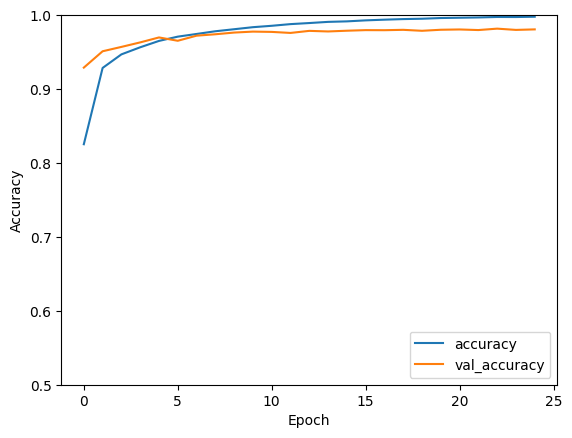

In [3]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])



history = model.fit(x_train, y_train, epochs=25, validation_data=(x_test, y_test), callbacks=[tb_callback])
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print('\nTest accuracy:', test_acc)

Val accuracy of 98.05% achieved. !!Sucess!! now for some experimenting with the learning rate.

In [7]:
import datetime
import os

np.random.seed(42)

lrates = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0] # must be float

# creating a catalog

#base_dir = r"C:\Users\nisse\Skola\DIL700"
#log_dir = os.path.join(base_dir, "logs", "fit", time.strftime("%Y%m%d-%H%M%S")) 

for lr in lrates:

    #rebuilding the model for each session
    keras.backend.clear_session()

    model = keras.Sequential([
    keras.layers.Dense(784, activation='relu', input_shape=(28*28,)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
    ])

    base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment3.1"

    log_dir = os.path.join(
        base_dir, "logs", "fit",
        f"lr_{lr}",
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )

    tb_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1)

    model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
              metrics=["accuracy"])
    
    history = model.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.1,
    callbacks=[tb_callback],
    batch_size=32
)


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.0968 - loss: 2.3295 - val_accuracy: 0.1173 - val_loss: 2.3249
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.0974 - loss: 2.3295 - val_accuracy: 0.1173 - val_loss: 2.3249
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.0965 - loss: 2.3302 - val_accuracy: 0.1173 - val_loss: 2.3249
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0964 - loss: 2.3301 - val_accuracy: 0.1173 - val_loss: 2.3249
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0957 - loss: 2.3298 - val_accuracy: 0.1175 - val_loss: 2.3248
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0971 - loss: 2.3294 - val_accuracy: 0.1175 - val_loss: 2.3248
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0955 - loss: 2.3306 - val_accuracy: 0.1175 - val_loss: 2.3248
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0977 - loss: 

the test starts by trying out different learning rates starting with 1e-7 up until 100000.0. for each run the learning rate is multiplied by ten. a learning rate of 0.1 was found to be the optimal one. Not only did it train fast but the results was also the best performing a validated accuracy of 98.65 % (!). when trying out a learning rate if 1.0 the results crashed and burn in comparison. The validation score is even under 10 % for ten classes.
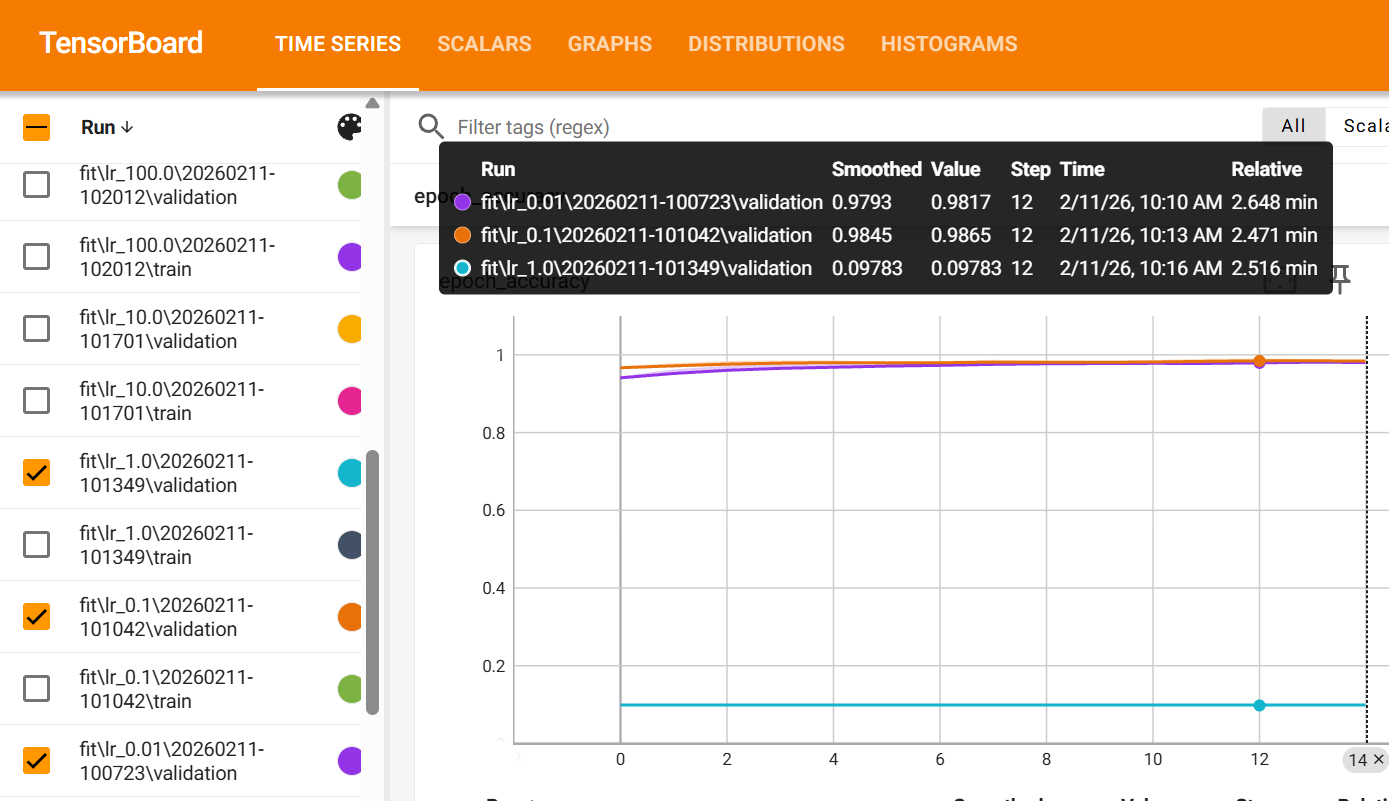
